In [ ]:
import sqlite3
import pandas as pd
import warnings
import alphalens
%matplotlib inline

warnings.filterwarnings("ignore")


DB_PATH = "./data/gm.db"
LOOKBACK_PERIOD = 40
THRESHOLD = 0.02


def get_all_tables():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name LIKE '____-__-__' ORDER BY name"
    )
    tables = [t[0] for t in cursor.fetchall()]
    conn.close()
    return tables


def load_price_data(tables):
    all_data = []
    conn = sqlite3.connect(DB_PATH)
    for i, table in enumerate(tables):
        try:
            df = pd.read_sql_query(
                f'SELECT symbol, close, adj_factor FROM "{table}"', conn
            )
            df["trade_date"] = table
            all_data.append(df)
            if (i + 1) % 500 == 0:
                print(f"已加载价格 {i + 1}/{len(tables)} 个交易日")
        except Exception as e:
            print(f"加载 {table} 失败: {e}")
    conn.close()
    return pd.concat(all_data, ignore_index=True)


def calculate_profit_frequency(tables):
    """计算盈利频率因子"""
    print("加载价格数据计算盈利频率...")
    conn = sqlite3.connect(DB_PATH)
    
    all_data = []
    for i, table in enumerate(tables):
        try:
            df = pd.read_sql_query(f'SELECT symbol, close, adj_factor FROM "{table}"', conn)
            df["trade_date"] = table
            all_data.append(df)
        except Exception as e:
            print(f"加载 {table} 失败: {e}")
    
    conn.close()
    
    price_df = pd.concat(all_data, ignore_index=True)
    price_df["adj_close"] = price_df["close"] * price_df["adj_factor"]
    price_df = price_df.pivot(index="trade_date", columns="symbol", values="adj_close")
    price_df = price_df.sort_index()
    print(f"价格矩阵形状: {price_df.shape}")
    
    returns = price_df.pct_change()
    market_mean = returns.mean(axis=1)
    excess_returns = returns.sub(market_mean, axis=0)
    
    above_threshold = (excess_returns > THRESHOLD).astype(int)
    profit_freq = above_threshold.rolling(window=LOOKBACK_PERIOD, min_periods=LOOKBACK_PERIOD).sum() / LOOKBACK_PERIOD
    
    factor_df = profit_freq.reset_index().melt(id_vars="trade_date", var_name="symbol", value_name="profit_freq")
    factor_df = factor_df.dropna(subset=["profit_freq"])
    
    return factor_df


def prepare_alphalens_data(factor_df, price_df, factor_name):
    factor_df = factor_df.rename(columns={factor_name: "factor"})
    factor_df = factor_df.dropna(subset=["factor"])
    factor_df = factor_df.set_index(["trade_date", "symbol"])["factor"]
    factor_df.index = pd.MultiIndex.from_tuples(
        [(pd.Timestamp(d), s) for d, s in factor_df.index], names=["date", "asset"]
    )

    price_df["adj_close"] = price_df["close"] * price_df["adj_factor"]
    price_df = price_df.set_index(["trade_date", "symbol"])["adj_close"]
    price_df.index = pd.MultiIndex.from_tuples(
        [(pd.Timestamp(d), s) for d, s in price_df.index], names=["date", "asset"]
    )
    price_df = price_df.unstack()
    price_df.index = pd.DatetimeIndex(price_df.index)

    return factor_df, price_df


def run_alphalens_test(start_date=None, end_date=None):
    print("加载数据...")
    tables = get_all_tables()

    if start_date:
        tables = [t for t in tables if t >= start_date]
    if end_date:
        tables = [t for t in tables if t <= end_date]

    print(f"选择交易日: {tables[0]} 至 {tables[-1]}, 共 {len(tables)} 天")

    print("计算盈利频率因子...")
    factor_df = calculate_profit_frequency(tables)
    print(f"因子数据量: {len(factor_df)}")

    print("加载价格数据...")
    price_df = load_price_data(tables)
    print(f"价格数据量: {len(price_df)}")

    print("准备alphalens格式数据...")
    factor_series, prices = prepare_alphalens_data(factor_df, price_df, "profit_freq")
    print(f"因子数据点数: {len(factor_series)}")
    print(f"价格数据形状: {prices.shape}")

    print("计算前向收益并清洗数据...")
    factor_data = alphalens.utils.get_clean_factor_and_forward_returns(
        factor_series, prices, periods=(5, 10, 20), quantiles=5
    )
    print(f"清洗后数据量: {len(factor_data)}")

    print("\n回测完成!")
    return factor_data


tables = get_all_tables()
print(f"数据库日期范围: {tables[0]} 至 {tables[-1]}")

start_date = "2020-01-01"
end_date = "2026-01-01"

factor_data = run_alphalens_test(start_date, end_date)


数据库日期范围: 2013-01-04 至 2026-01-30
加载数据...
选择交易日: 2020-01-02 至 2025-12-31, 共 1455 天
计算盈利频率因子...
加载价格数据计算盈利频率...
价格矩阵形状: (1455, 5388)
因子数据量: 7629408
加载价格数据...
已加载价格 500/1455 个交易日
已加载价格 1000/1455 个交易日
价格数据量: 6841902
准备alphalens格式数据...
因子数据点数: 7629408
价格数据形状: (1455, 5388)
计算前向收益并清洗数据...
Dropped 11.7% entries from factor data: 11.7% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
清洗后数据量: 6737026

回测完成!



生成Full Tear Sheet...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.000,0.100,0.038422,0.026667,1695810,25.171493
2,0.050,0.150,0.091988,0.025026,1382941,20.527470
3,0.075,0.200,0.138802,0.027392,1309949,19.444025
4,0.125,0.275,0.191397,0.031847,1200816,17.824126
5,0.175,0.900,0.288476,0.064607,1147510,17.032887


Returns Analysis


,5D,10D,20D
Ann. alpha,-0.120,-0.109,-0.096
beta,0.059,0.065,0.090
Mean Period Wise Return Top Quantile (bps),-37.438,-33.705,-28.341
Mean Period Wise Return Bottom Quantile (bps),14.761,12.839,10.015
Mean Period Wise Spread (bps),-52.199,-46.899,-38.905


<Figure size 640x480 with 0 Axes>

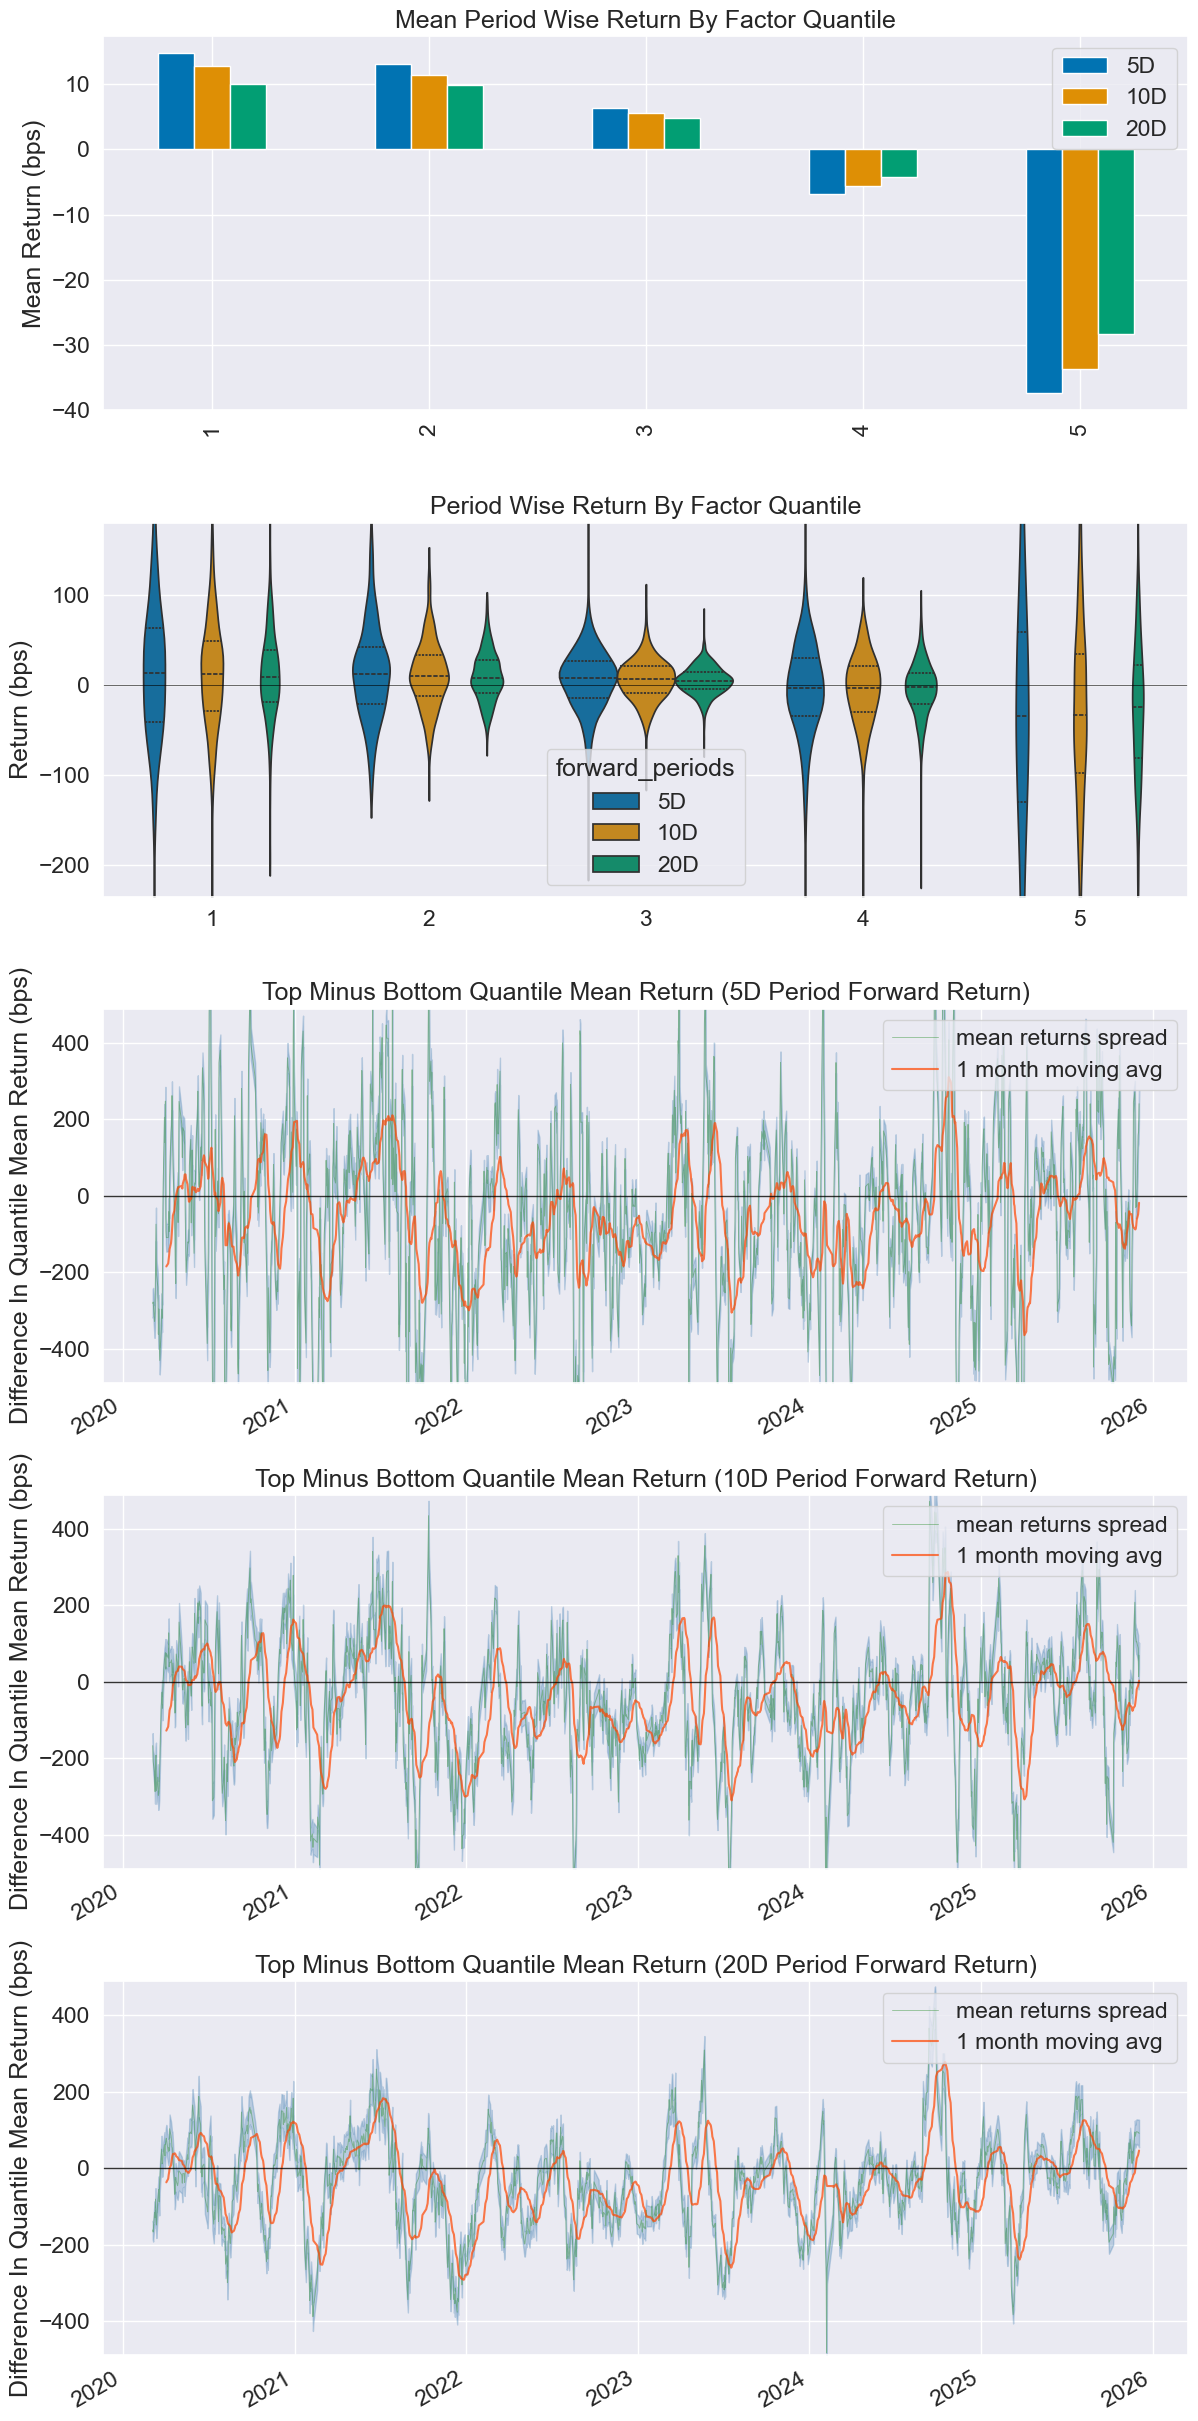

Information Analysis


,5D,10D,20D
IC Mean,-0.083,-0.096,-0.110
IC Std.,0.133,0.135,0.144
Risk-Adjusted IC,-0.626,-0.715,-0.762
t-stat(IC),-23.405,-26.706,-28.473
p-value(IC),0.000,0.000,0.000
IC Skew,-0.096,-0.225,-0.245
IC Kurtosis,-0.053,-0.192,-0.364


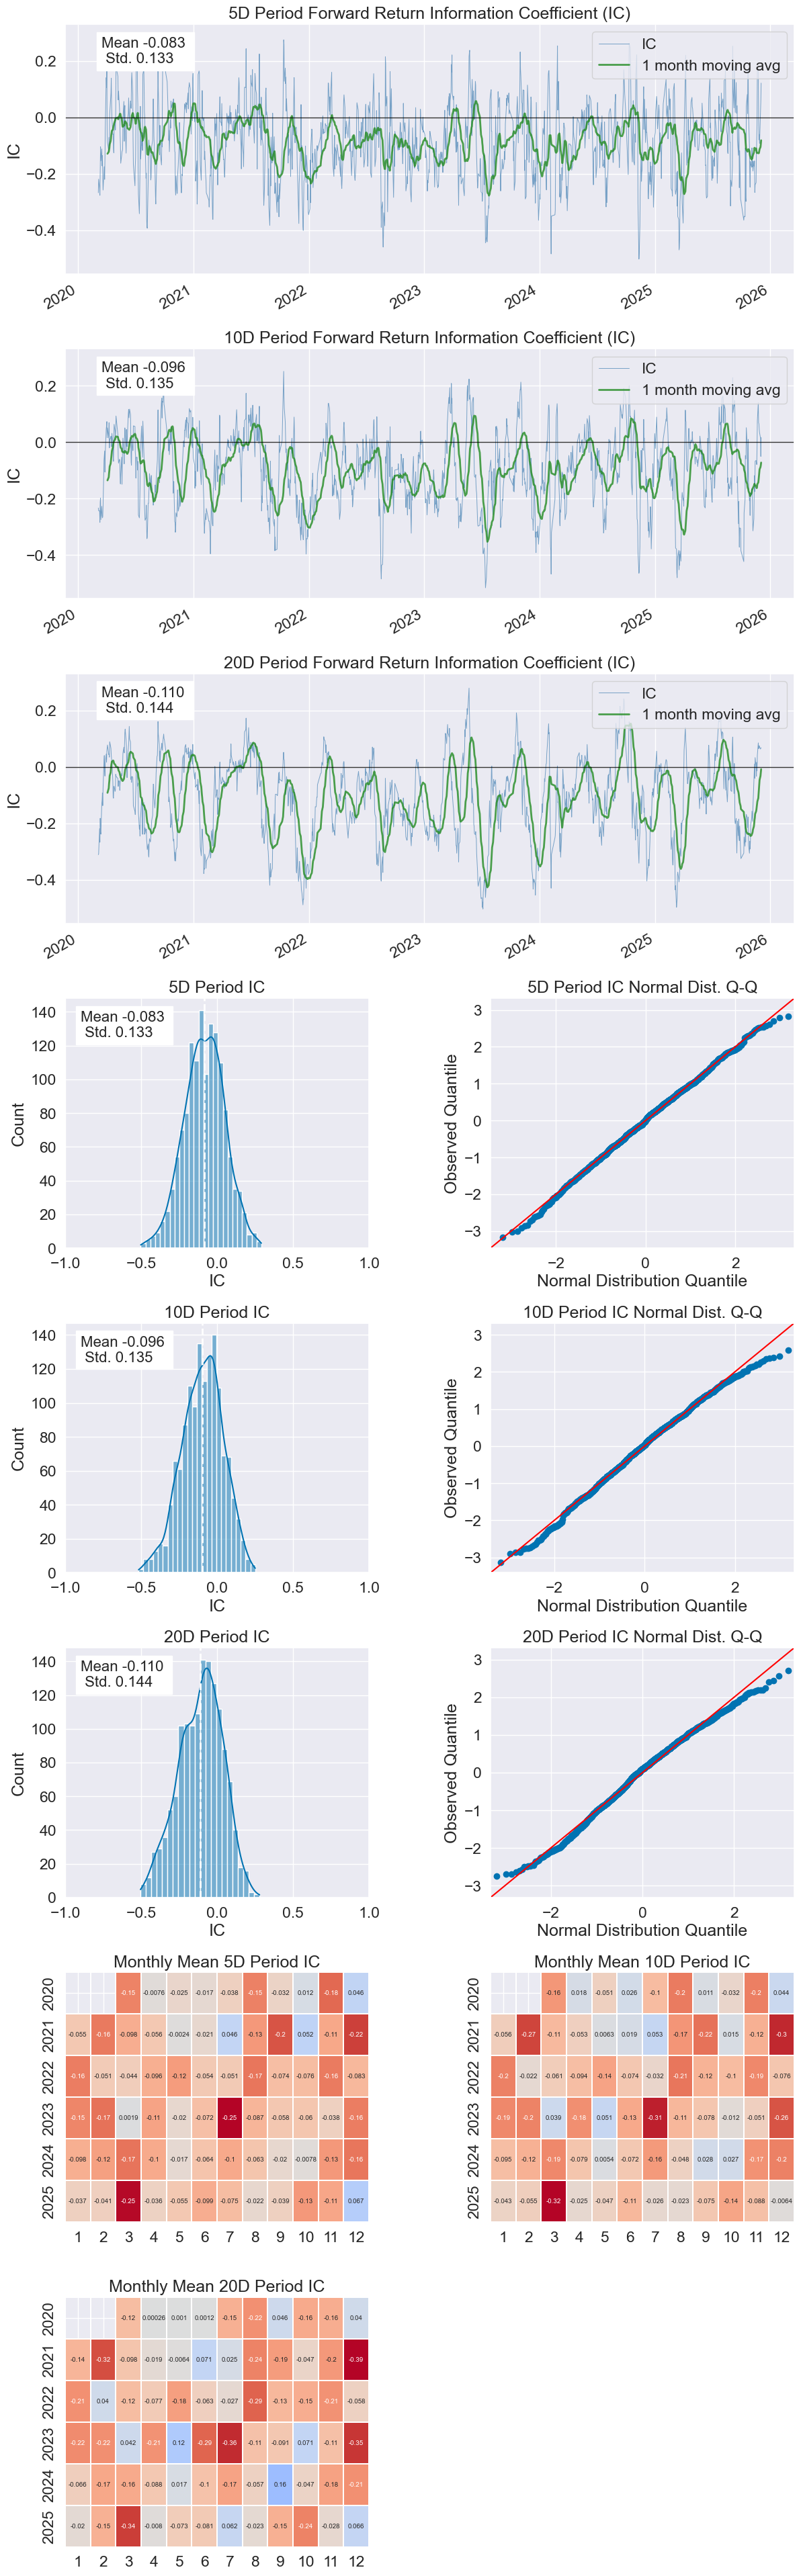

Turnover Analysis


,5D,10D,20D
Quantile 1 Mean Turnover,0.155,0.249,0.386
Quantile 2 Mean Turnover,0.393,0.546,0.679
Quantile 3 Mean Turnover,0.434,0.587,0.713
Quantile 4 Mean Turnover,0.401,0.552,0.685
Quantile 5 Mean Turnover,0.179,0.277,0.430


,5D,10D,20D
Mean Factor Rank Autocorrelation,0.941,0.871,0.711


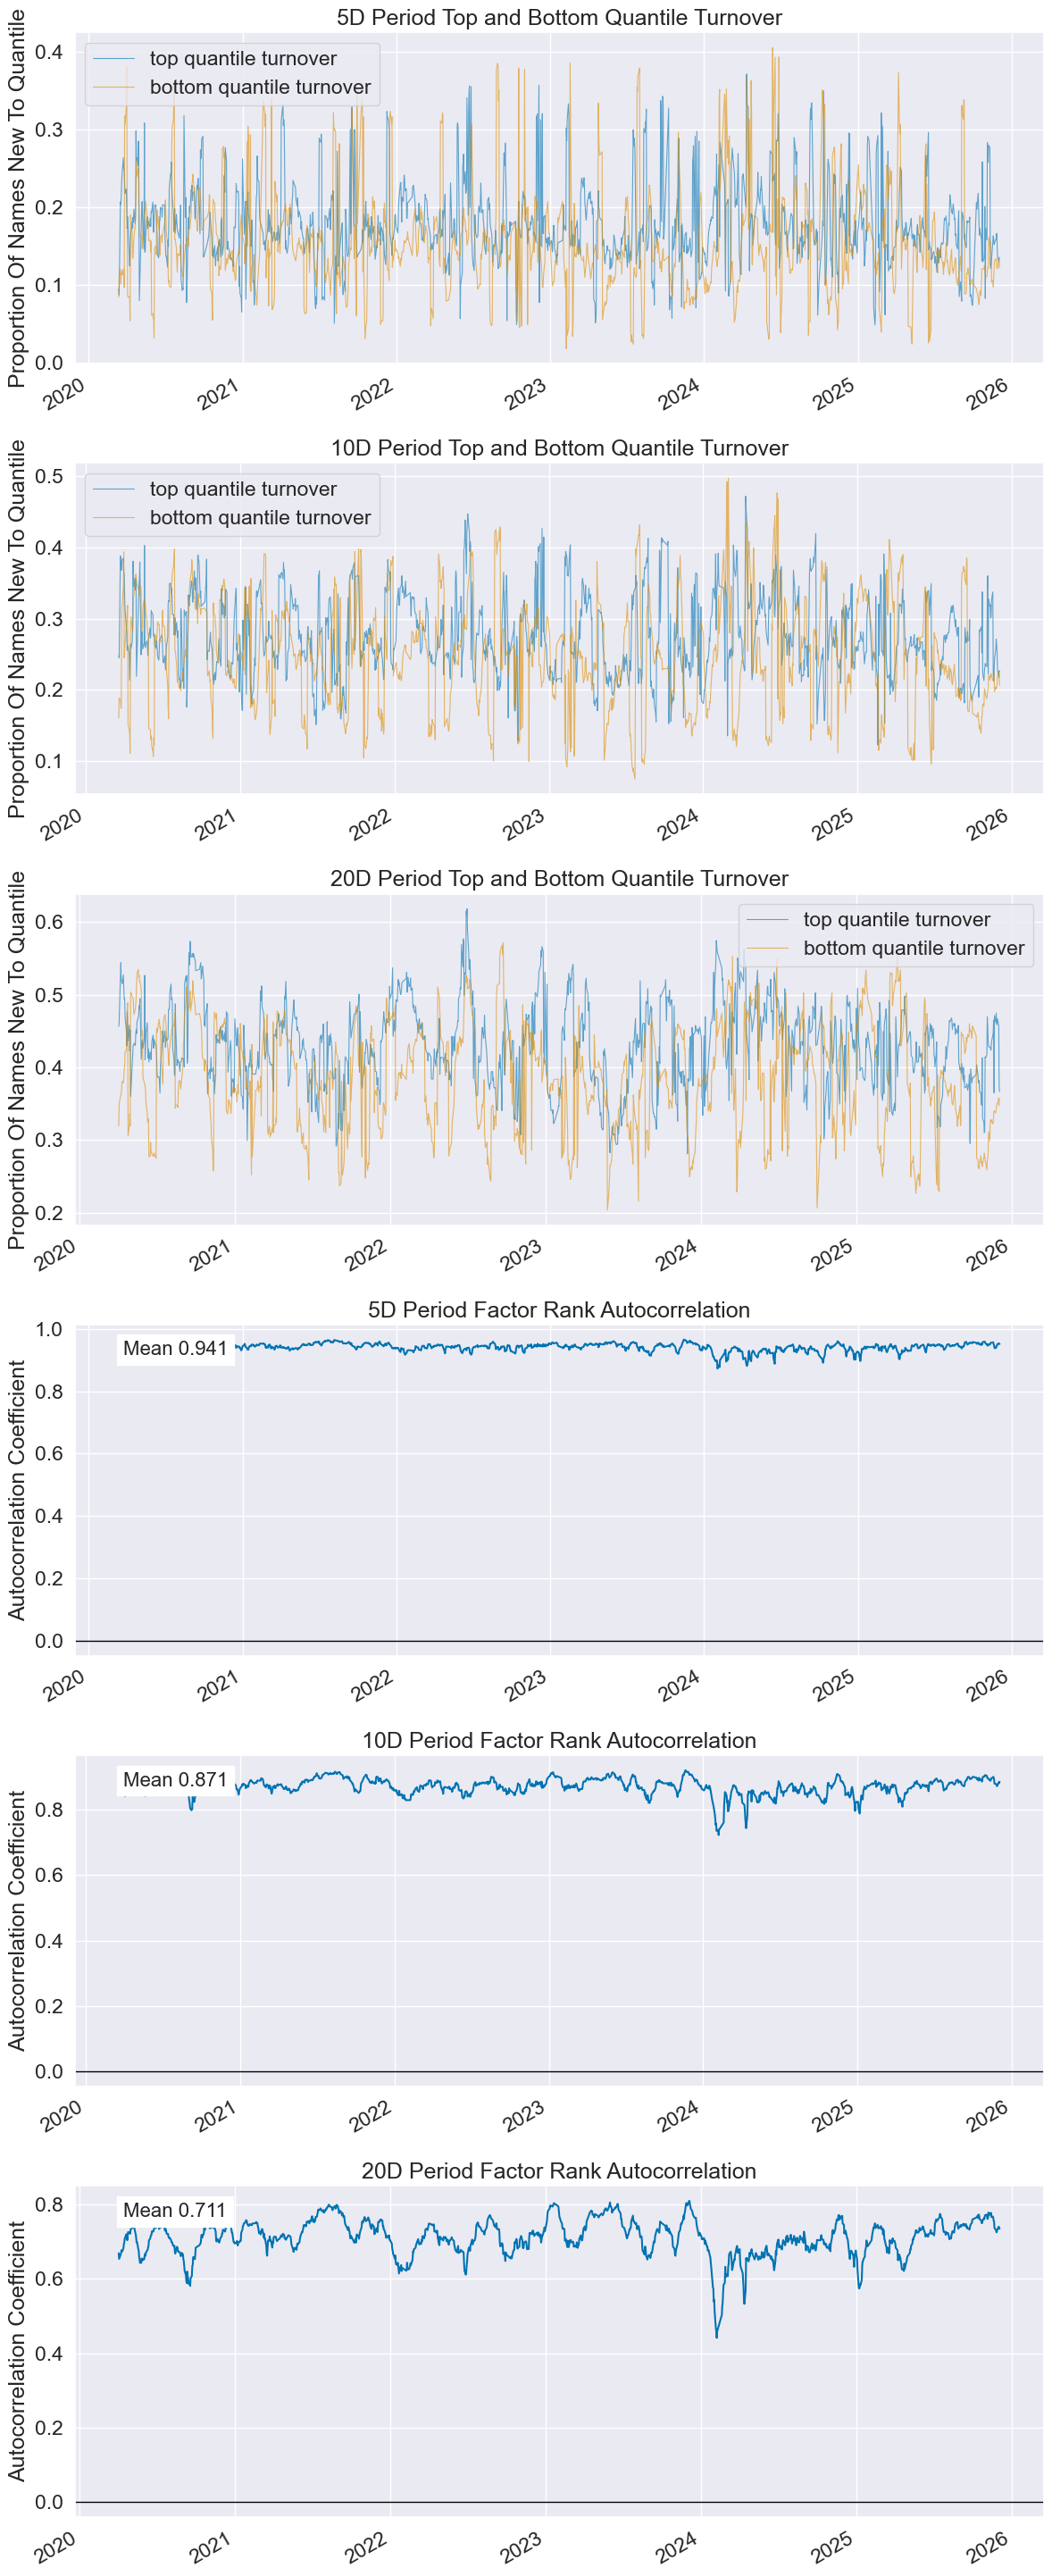

In [4]:
print("\n生成Full Tear Sheet...")
alphalens.tears.create_full_tear_sheet(factor_data, long_short=True, group_neutral=False, by_group=False)
